# *** ANALISIS EXPLORATORIO DE DATOS TITANIC- EJERCICIO ***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

In [3]:
titanic_df = sns.load_dataset('titanic')
titanic_df.dropna(inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


# PREGUNTAS BASICAS

## ¿QUE TIPO DE DATO TIENEN LAS VARIABLES DEL DATASET?

In [6]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [5]:
for col in titanic_df.select_dtypes(include='category').columns:
    titanic_df[col] = titanic_df[col].astype('object')

## ¿ CUÁNTAS VARIABLES DE CADA TIPO DE DATO TENEMOS EN EL DATASET?

In [7]:
titanic_df.dtypes.value_counts()

,count
object,7
int64,4
float64,2
bool,2


## ¿ CUÁNTAS VARIABLES(COLUMNAS) Y OBSERVACIONES(FILAS) TENEMOS EN EL DATASET?

In [8]:
titanic_df.shape

(182, 15)

# CONTEOS Y PROPORCIONES

## CONTEO DE VARIABLES NÚMERICAS

In [9]:
titanic_df.describe(include=[np.number])

,survived,pclass,age,sibsp,parch,fare
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,0.675824,1.192308,35.623187,0.467033,0.478022,78.919735
std,0.469357,0.516411,15.671615,0.645007,0.755869,76.490774
min,0.000000,1.000000,0.920000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,24.000000,0.000000,0.000000,29.700000
50%,1.000000,1.000000,36.000000,0.000000,0.000000,57.000000
75%,1.000000,1.000000,47.750000,1.000000,1.000000,90.000000
max,1.000000,3.000000,80.000000,3.000000,4.000000,512.329200


## CONTEO DE VARIABLES CATEGORICAS(sexo y clase)

In [10]:
titanic_df[['sex', 'class']].describe()

,sex,class
count,182,182
unique,2,3
top,male,First
freq,94,157


## GRAFICO DE CONTEOS

In [11]:
titanic_df['class'].value_counts()

,count
class,
First,157
Second,15
Third,10


In [12]:
class_color = {
    'First': '#ff6602ff',
    'Second': '#0f7175ff',
    'Third': '#c65dc9ff'
}

<Axes: title={'center': 'Cantidad de Pasajeros por Clase'}, xlabel='class'>

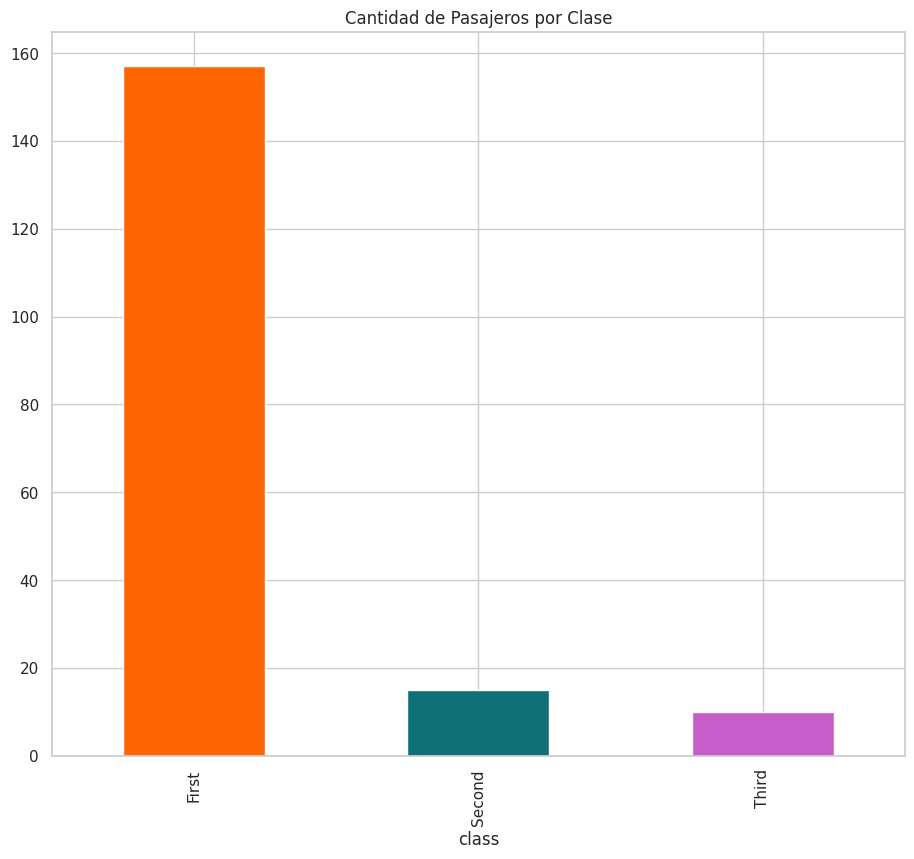

In [13]:
(
    titanic_df
    ['class']
    .value_counts()
    .plot(kind='bar',
          color=class_color.values(),
          title='Cantidad de Pasajeros por Clase')
)

## GRAFICO DE PROPORCIONES

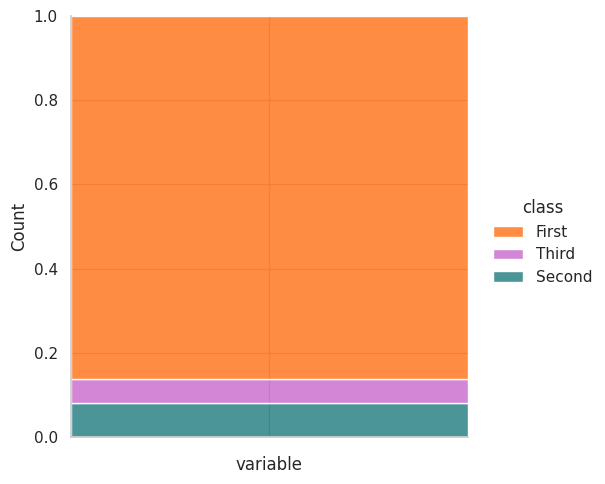

In [14]:
titanic_df['variable'] = ''
(
    titanic_df
    .pipe(
        lambda df:(
            sns.displot(
                data=df,
                x='variable',
                hue='class',
                multiple='fill',
                palette=class_color
            )
        )
    )
)

## GRAFICO DE MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN DE LA VARIABLE AGE

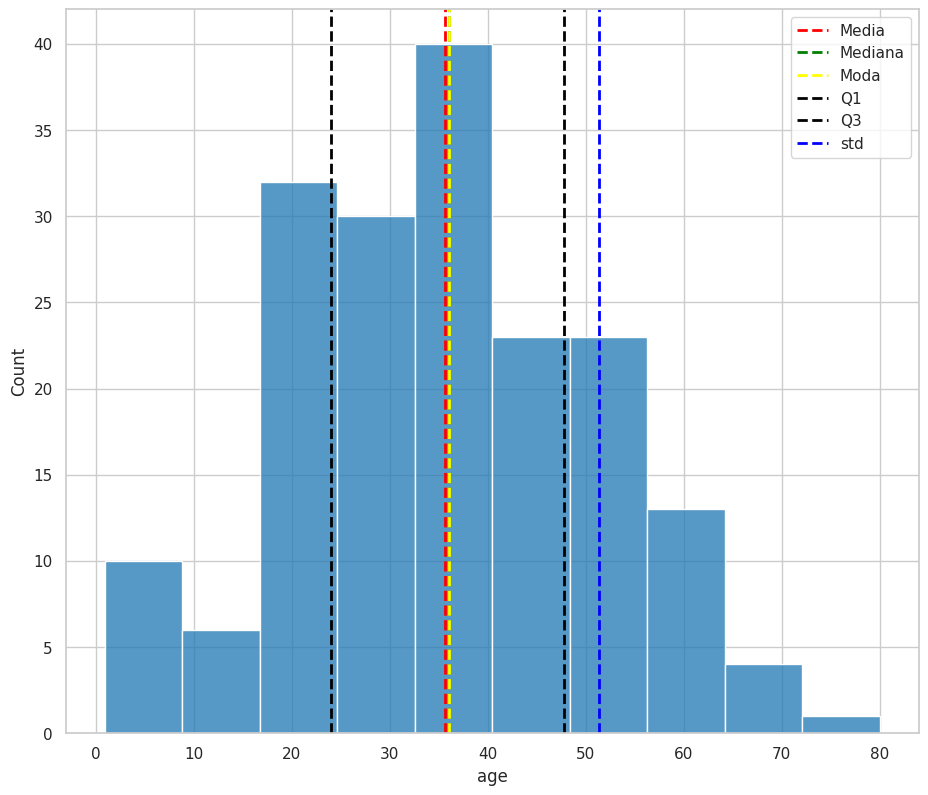

In [15]:
variable = 'age'

sns.histplot(
    data=titanic_df,
    x=variable
)

# MEDIA
plt.axvline(
    x=titanic_df[variable].mean(),
    label='Media',
    color='red',
    linestyle='dashed',
    linewidth=2
)

# MEDIANA
plt.axvline(
    x=titanic_df[variable].median(),
    label='Mediana',
    color='green',
    linestyle='dashed',
    linewidth=2
)

#MODA
plt.axvline(
    x=titanic_df[variable].mode().values[0],
    label='Moda',
    color='yellow',
    linestyle='dashed',
    linewidth=2
)


#Q 25
plt.axvline(
    x=titanic_df[variable].quantile(0.25),
    label='Q1',
    color='black',
    linestyle='dashed',
    linewidth=2
)

#Q 75
plt.axvline(
    x=titanic_df[variable].quantile(0.75),
    label='Q3',
    color='black',
    linestyle='dashed',
    linewidth=2
)


# std
plt.axvline(
    x=titanic_df[variable].mean() + titanic_df[variable].std(),
    label='std',
    color='blue',
    linestyle='dashed',
    linewidth=2
)

plt.legend()

plt.show()